# 🛍️ E-Commerce Customer Analytics with Python

## 1. 📋 Project Overview

Customer analytics enables businesses to better understand purchasing behavior, identify high-value customers, improve customer retention, and develop data-driven marketing strategies.

In this project, a cleaned transactional e-commerce dataset is transformed into a customer-level dataset to analyze purchasing behavior, segment customers using the RFM (Recency, Frequency, Monetary) framework, estimate Customer Lifetime Value (CLV), and identify the customers who contribute the greatest share of revenue.

The analysis provides actionable insights that support customer retention, personalized marketing, and revenue growth while demonstrating practical business analytics techniques using Python.

---
## 2. 🎯 Business Problem

This project aims to answer the following business questions:

1. How many unique customers does the business have?
2. Who are the highest-value customers by revenue?
3. How frequently do customers make purchases?
4. What is the average order value per customer?
5. What percentage of customers purchase only once?
6. Which countries generate the highest customer revenue?
7. Which customer segments generate the most revenue?
8. Who are the most loyal customers based on RFM analysis?
9. Which customers are at risk of churning?
10. How much revenue is generated by the top 20% of customers?
11. What is the estimated Customer Lifetime Value (CLV) of customers?
12. What business strategies can improve customer retention and profitability?

---
## 📑 Table of Contents

1. [📋 Project Overview](#1-project-overview)
2. [🎯 Business Problem](#2-business-problem)
3. [🧹 Data Preparation & Cleaning](#3-data-preparation--cleaning)
4. [⚙️ Feature Engineering](#4-feature-engineering)
5. [👥 Customer Dataset Creation](#5-customer-dataset-creation)
6. [📈 Customer Behavior Analysis](#6-customer-behavior-analysis)
7. [🎯 RFM Customer Segmentation](#7-rfm-customer-segmentation)
8. [💰 Customer Value Analysis](#8-customer-value-analysis)
9. [📊 Data Visualization & Insights](#9-data-visualization--insights)
10. [💡 Executive Business Recommendations](#10-executive-business-recommendations)

## 3. 🧹 Data Preparation & Cleaning

Before performing customer analytics, the dataset is prepared for analysis by carrying out the following steps:

- Inspect the dataset structure (`shape`, `info`, and `head`).
- Verify the data types of each column.
- Check for any remaining missing values.
- Convert the `InvoiceDate` column to the datetime format.
- Confirm there are no duplicate customer records or unexpected anomalies.
- Prepare the dataset for customer-level feature engineering.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ugwuonudennis/online-retail-cleaned/online_retail_cleaned.csv
/kaggle/input/datasets/ugwuonudennis/online-retail-cleaned/images/country_sales_excluding_uk.png
/kaggle/input/datasets/ugwuonudennis/online-retail-cleaned/images/top_products.png
/kaggle/input/datasets/ugwuonudennis/online-retail-cleaned/images/country_sales.png
/kaggle/input/datasets/ugwuonudennis/online-retail-cleaned/images/revenue_by_weekday.png
/kaggle/input/datasets/ugwuonudennis/online-retail-cleaned/images/top_customers.png
/kaggle/input/datasets/ugwuonudennis/online-retail-cleaned/images/monthly_revenue_trend.png


In [2]:
df = pd.read_csv('/kaggle/input/datasets/ugwuonudennis/online-retail-cleaned/online_retail_cleaned.csv')

df.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom


### 3.1 Dataset Dimensions

In [3]:
df.shape

(392693, 8)

### 3.2 Dataset Columns

In [4]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

### 3.3 Dataset information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392693 entries, 0 to 392692
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    392693 non-null  int64  
 1   StockCode    392693 non-null  object 
 2   Description  392693 non-null  object 
 3   Quantity     392693 non-null  int64  
 4   InvoiceDate  392693 non-null  object 
 5   UnitPrice    392693 non-null  float64
 6   CustomerID   392693 non-null  float64
 7   Country      392693 non-null  object 
dtypes: float64(2), int64(2), object(4)
memory usage: 24.0+ MB


### 3.4 Check Missing Values

In [6]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

### 3.5 Convert InvoiceDate to Datetime

In [7]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["InvoiceDate"].head(3)

0   2010-12-01 08:26:00
1   2010-12-01 08:26:00
2   2010-12-01 08:26:00
Name: InvoiceDate, dtype: datetime64[ns]

### 3.6 Verify data type

In [8]:
df.dtypes

InvoiceNo               int64
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

### 3.7 Summary Statitics

In [9]:
df.describe()

,InvoiceNo,Quantity,InvoiceDate,UnitPrice,CustomerID
count,392693.000000,392693.000000,392693,392693.000000,392693.000000
mean,560590.928514,13.119671,2011-07-10 19:13:41.156272128,3.125952,15287.837224
min,536365.000000,1.000000,2010-12-01 08:26:00,0.001000,12346.000000
25%,549234.000000,2.000000,2011-04-07 11:12:00,1.250000,13955.000000
50%,561874.000000,6.000000,2011-07-31 12:02:00,1.950000,15150.000000
75%,572061.000000,12.000000,2011-10-20 12:53:00,3.750000,16791.000000
max,581587.000000,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000
std,13087.089985,180.492603,NaN,22.241820,1713.542421


## 4. ⚙️ Feature Engineering

To support customer-level analysis, new features are created from the transactional data. These engineered features provide the foundation for customer segmentation, behavioral analysis, and Customer Lifetime Value (CLV) estimation.

The following features are created:

- **Revenue** = Quantity × Unit Price
- **Invoice Year** extracted from the invoice date
- **Invoice Month** extracted from the invoice date
- **Invoice Quarter** extracted from the invoice date
- **Invoice Day** extracted from the invoice date
- **Invoice Weekday** extracted from the invoice date

In [10]:
# Create Revenue Column

df["Revenue"] = df["Quantity"] * df["UnitPrice"]
df.head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [11]:
# Create date-related columns

# Year
df["InvoiceYear"] = df["InvoiceDate"].dt.year

# Month
df["InvoiceMonth"] = df["InvoiceDate"].dt.month_name()

# Quarter
df["InvoiceQuarter"] = df["InvoiceDate"].dt.quarter

# Day of Month
df["InvoiceDay"] = df["InvoiceDate"].dt.day

# Day of Week
df["InvoiceWeekday"] = df["InvoiceDate"].dt.day_name()
df.head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,InvoiceYear,InvoiceMonth,InvoiceQuarter,InvoiceDay,InvoiceWeekday
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,December,4,1,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,December,4,1,Wednesday


## 5. 👥 Customer Dataset Creation

The original dataset contains one row per transaction. For customer analytics, the data must be aggregated so that each row represents a unique customer.

A customer-level dataset is created by summarizing each customer's purchasing history and calculating key performance metrics that describe their purchasing behavior.

The following features are generated for each customer:

- **Customer ID** – Unique customer identifier.
- **Total Revenue** – Total amount spent by the customer.
- **Total Orders** – Number of unique orders placed.
- **Total Quantity Purchased** – Total number of items purchased.
- **Average Order Value (AOV)** – Average amount spent per order.
- **First Purchase Date** – Date of the customer's first purchase.
- **Last Purchase Date** – Date of the customer's most recent purchase.
- **Customer Tenure (Days)** – Number of days between the first and last purchase.
- **Purchase Frequency** – Average number of orders per day during the customer's active period.

The resulting customer-level dataset serves as the foundation for customer behavior analysis, RFM segmentation, and Customer Lifetime Value estimation.

####  5.1 Aggregate Customer Metrics

In [12]:
# Aggregate customer metrics {CustomerID, TotalRevenue, TotalOrders, TotalQuantity, FirstPurchaseDate, LastPurchaseDate}

customer_summary = (
                        df.groupby("CustomerID")
                          .agg(
                        TotalRevenue = ("Revenue", "sum"),
                        TotalOrders = ("InvoiceNo", "nunique"),
                        TotalQuantity = ("Quantity", "sum"),
                        FirstPurchase = ("InvoiceDate", "min"),
                        LastPurchase = ("InvoiceDate", "max")
                          )
                          .reset_index()
)
customer_summary.head(2)

,CustomerID,TotalRevenue,TotalOrders,TotalQuantity,FirstPurchase,LastPurchase
0,12346.0,77183.6,1,74215,2011-01-18 10:01:00,2011-01-18 10:01:00
1,12347.0,4310.0,7,2458,2010-12-07 14:57:00,2011-12-07 15:52:00


In [13]:
customer_summary = customer_summary.set_index("CustomerID")

In [14]:
print(customer_summary.index.name)
print(customer_summary.index[:10].tolist())

CustomerID
[12346.0, 12347.0, 12348.0, 12349.0, 12350.0, 12352.0, 12353.0, 12354.0, 12355.0, 12356.0]


####  5.2 Average Order Value

In [15]:
# Average Order Value - average amount spent per order

customer_summary["AverageOrderValue"] = customer_summary["TotalRevenue"] / customer_summary["TotalOrders"]
customer_summary.head(2)

,TotalRevenue,TotalOrders,TotalQuantity,FirstPurchase,LastPurchase,AverageOrderValue
CustomerID,,,,,,
12346.0,77183.6,1,74215,2011-01-18 10:01:00,2011-01-18 10:01:00,77183.600000
12347.0,4310.0,7,2458,2010-12-07 14:57:00,2011-12-07 15:52:00,615.714286


#### 5.3 Customer Tenure

In [16]:
# Customer Tenure (Days) - number of days between the first and last purchase

customer_summary["CustomerTenure"] = (customer_summary["LastPurchase"] - customer_summary["FirstPurchase"]).dt.days
customer_summary.head(2)

,TotalRevenue,TotalOrders,TotalQuantity,FirstPurchase,LastPurchase,AverageOrderValue,CustomerTenure
CustomerID,,,,,,,
12346.0,77183.6,1,74215,2011-01-18 10:01:00,2011-01-18 10:01:00,77183.600000,0
12347.0,4310.0,7,2458,2010-12-07 14:57:00,2011-12-07 15:52:00,615.714286,365


#### 5.4 Purchase Frequency 

In [17]:
# Purchase Frequency - Average number of orders per day during the customer's active period
            # Since customers who purchased only one day have 0 tenure days, replace the 0 by 1 to avoid division by zero

customer_summary["PurchaseFrequency"] = (customer_summary["TotalOrders"] / customer_summary["CustomerTenure"].replace(0,1)
                                        )
customer_summary.head(2)

,TotalRevenue,TotalOrders,TotalQuantity,FirstPurchase,LastPurchase,AverageOrderValue,CustomerTenure,PurchaseFrequency
CustomerID,,,,,,,,
12346.0,77183.6,1,74215,2011-01-18 10:01:00,2011-01-18 10:01:00,77183.600000,0,1.000000
12347.0,4310.0,7,2458,2010-12-07 14:57:00,2011-12-07 15:52:00,615.714286,365,0.019178


#### 5.5 Preview the customer dataset

In [18]:
customer_summary.info()
customer_summary.shape

<class 'pandas.core.frame.DataFrame'>
Index: 4338 entries, 12346.0 to 18287.0
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   TotalRevenue       4338 non-null   float64       
 1   TotalOrders        4338 non-null   int64         
 2   TotalQuantity      4338 non-null   int64         
 3   FirstPurchase      4338 non-null   datetime64[ns]
 4   LastPurchase       4338 non-null   datetime64[ns]
 5   AverageOrderValue  4338 non-null   float64       
 6   CustomerTenure     4338 non-null   int64         
 7   PurchaseFrequency  4338 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(3)
memory usage: 305.0 KB


(4338, 8)

#### 5.6 Save the customer dataset

In [19]:
customer_summary.to_csv("customer_summary.csv", index = False)
#customer_summary

## 6. 📈 Customer Behavior Analysis

The customer-level dataset created during the data preparation stage provides the foundation for analyzing customer purchasing behavior.

This section examines how customers interact with the business by analyzing their spending patterns, purchase frequency, repeat purchasing behavior, and geographic performance.

The analysis focuses on the following key areas:

* **Customer Base** – Determine the total number of unique customers served during the analysis period.
* **Customer Spending** – Analyze average customer spending and the distribution of revenue across customers.
* **Purchase Behavior** – Compare one-time customers with repeat customers to understand customer retention and purchasing patterns.
* **Top Customers** – Identify the highest-value customers based on total revenue generated.
* **Geographic Performance** – Evaluate customer and revenue performance across different countries.
* **Purchase Frequency** – Examine how frequently customers place orders and identify differences in purchasing activity.

Informative visualizations are created to communicate the major patterns and trends identified in the data. Each visualization is accompanied by a business insight explaining what the findings mean from a commercial perspective.

The objective of this analysis is to transform customer transaction data into actionable insights that can support **customer retention, targeted marketing, customer value management, and geographic growth strategies**.


In [20]:
customer_summary.head()

,TotalRevenue,TotalOrders,TotalQuantity,FirstPurchase,LastPurchase,AverageOrderValue,CustomerTenure,PurchaseFrequency
CustomerID,,,,,,,,
12346.0,77183.60,1,74215,2011-01-18 10:01:00,2011-01-18 10:01:00,77183.600000,0,1.000000
12347.0,4310.00,7,2458,2010-12-07 14:57:00,2011-12-07 15:52:00,615.714286,365,0.019178
12348.0,1797.24,4,2341,2010-12-16 19:09:00,2011-09-25 13:13:00,449.310000,282,0.014184
12349.0,1757.55,1,631,2011-11-21 09:51:00,2011-11-21 09:51:00,1757.550000,0,1.000000
12350.0,334.40,1,197,2011-02-02 16:01:00,2011-02-02 16:01:00,334.400000,0,1.000000


#### 6.1 Number of Unique Customers

Understanding the size of the customer base is an important first step in customer behavior analysis. This metric shows the number of distinct customers who made purchases during the analysis period.

In [21]:
unique_customers = customer_summary.index.nunique()

print(f"Number of Unique Customers: {unique_customers:,}")

Number of Unique Customers: 4,338


**Business Insight:**

The analysis shows that the business served **4,338 unique customers** during the period covered by the dataset. This represents the size of the identifiable customer base and provides a baseline for evaluating customer purchasing behavior, retention, and overall customer value.

#### 6.2 Average Customer Spend

Average customer spend measures the average amount of revenue generated by each customer during the analysis period. This provides an overall indication of customer value and helps establish a benchmark for comparing customer spending behavior.

In [22]:
average_customer_spend = customer_summary["TotalRevenue"].mean()

print(f"Average Customer Spend: £{average_customer_spend:,.2f}")

Average Customer Spend: £2,048.69


**Business Insight:**

The average customer generated approximately **£2,048.69** in revenue during the analysis period. This provides a useful benchmark for evaluating customer value and identifying customers whose spending is significantly above or below the overall average.

### 6.3 Revenue Distribution

Analyzing the distribution of customer revenue helps determine how evenly spending is distributed across the customer base. It can reveal whether most customers contribute similar amounts of revenue or whether a small group of high-value customers generates a disproportionate share of total revenue.

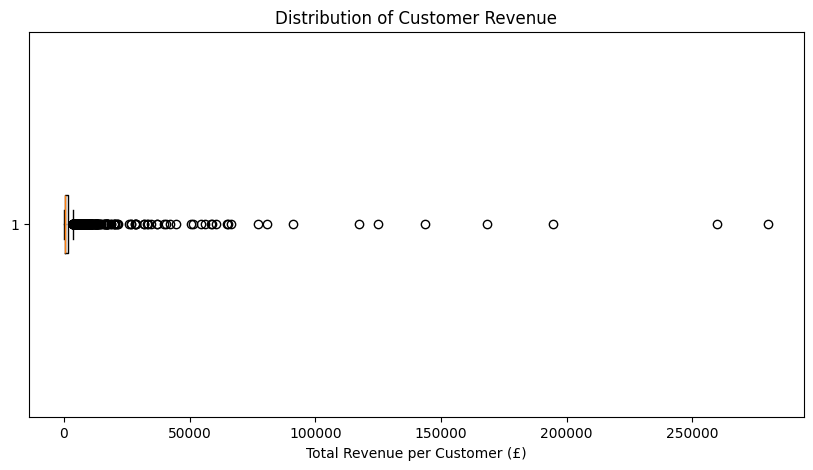

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.boxplot(customer_summary["TotalRevenue"], vert=False)

plt.title("Distribution of Customer Revenue")
plt.xlabel("Total Revenue per Customer (£)")

plt.show()

In [24]:
revenue_bins = [0, 500, 1000, 2500, 5000, 10000, float("inf")]

revenue_labels = [
    "£0–£500",
    "£501–£1,000",
    "£1,001–£2,500",
    "£2,501–£5,000",
    "£5,001–£10,000",
    "Above £10,000"
]

customer_summary["RevenueBand"] = pd.cut(
    customer_summary["TotalRevenue"],
    bins=revenue_bins,
    labels=revenue_labels,
    include_lowest=True
)

revenue_band_counts = customer_summary["RevenueBand"].value_counts().sort_index()

revenue_band_counts

RevenueBand
£0–£500           1765
£501–£1,000        909
£1,001–£2,500      963
£2,501–£5,000      427
£5,001–£10,000     170
Above £10,000      104
Name: count, dtype: int64

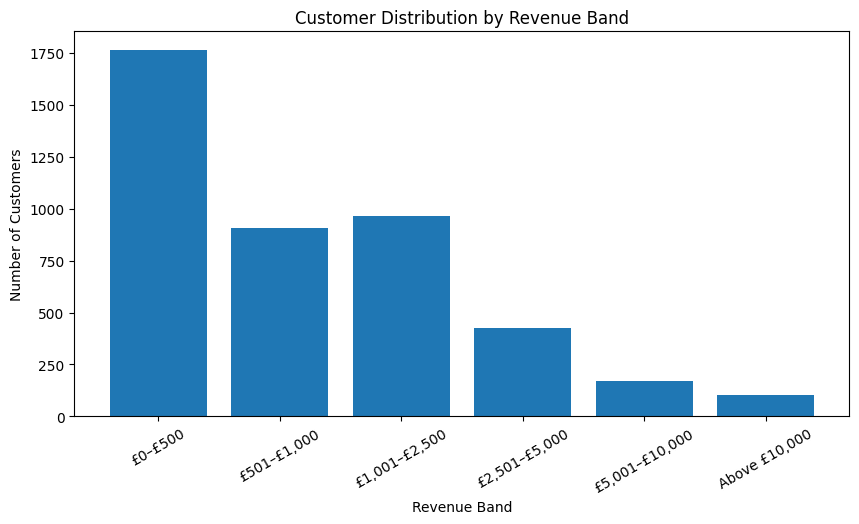

In [25]:
plt.figure(figsize=(10, 5))

plt.bar(
    revenue_band_counts.index,
    revenue_band_counts.values
)

plt.title("Customer Distribution by Revenue Band")
plt.xlabel("Revenue Band")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)

plt.show()

### 6.4 One-Time vs. Repeat Customers

Understanding the proportion of one-time and repeat customers provides insight into customer retention and purchasing behavior. Customers who make multiple purchases demonstrate stronger engagement with the business, while one-time customers may represent opportunities for retention and repeat-purchase campaigns.

In [26]:
customer_summary["CustomerType"] = np.where(customer_summary["TotalOrders"] == 1, "One-Time","Repeat")

customer_type_counts = customer_summary["CustomerType"].value_counts()

customer_type_counts

CustomerType
Repeat      2845
One-Time    1493
Name: count, dtype: int64

In [27]:
customer_type_percentage = (customer_type_counts / customer_type_counts.sum() * 100)

customer_type_percentage


CustomerType
Repeat      65.583218
One-Time    34.416782
Name: count, dtype: float64

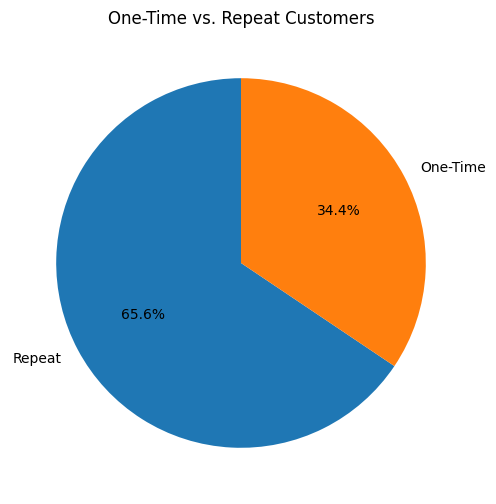

In [28]:
plt.figure(figsize=(6, 6))

plt.pie(
    customer_type_counts,
    labels=customer_type_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("One-Time vs. Repeat Customers")

plt.savefig(
    "one_time_vs_repeat_customers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Business Insight:**

The analysis shows that **65.6% of customers are repeat customers**, while **34.4% made only one purchase** during the analysis period. The relatively high proportion of repeat customers indicates strong customer engagement and suggests that the business has a solid base of returning customers.

However, the **34.4% one-time customer segment represents a significant retention opportunity**. Targeted follow-up campaigns, personalized offers, loyalty programs, and post-purchase engagement could help convert more one-time customers into repeat buyers.

### 6.5 Top Customers by Revenue

Identifying the highest-revenue customers helps the business understand which customers contribute the most to overall revenue. These high-value customers are important targets for retention strategies and personalized customer engagement.

In [29]:
top_customers = (
    customer_summary
    .sort_values("TotalRevenue", ascending=False)
    .head(10)
)
top_customers.reset_index()[["CustomerID", "TotalRevenue"]]

,CustomerID,TotalRevenue
0,14646.0,280206.02
1,18102.0,259657.30
2,17450.0,194390.79
3,16446.0,168472.50
4,14911.0,143711.17
5,12415.0,124914.53
6,14156.0,117210.08
7,17511.0,91062.38
8,16029.0,80850.84
9,12346.0,77183.60


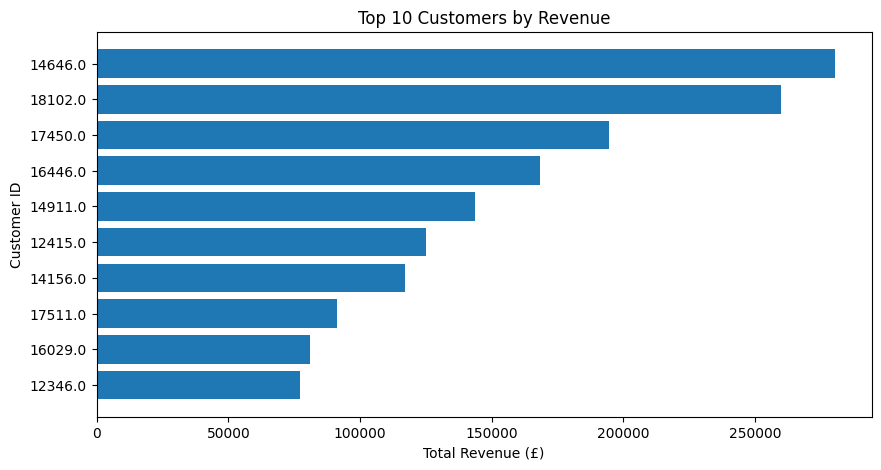

In [30]:
plt.figure(figsize=(10, 5))

plt.barh(
    top_customers.index.astype(str),
    top_customers["TotalRevenue"]
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Total Revenue (£)")
plt.ylabel("Customer ID")

plt.gca().invert_yaxis()

plt.show()

**Business Insight:**

The analysis shows a strong concentration of revenue among a small group of high-value customers. Customer **14646** generated the highest revenue at approximately **£280,206**, followed by Customer **18102** with approximately **£259,657**.

The top 10 customers each generated substantially more revenue than the average customer spend of **£2,048.69**, highlighting their importance to the business. These customers should be prioritized for retention through personalized offers, loyalty initiatives, and proactive relationship management.

At the same time, the significant difference between the highest-value customers and the broader customer base suggests that the business should identify opportunities to move more customers into higher-value segments.

### 6.6 Country-wise Customer Performance

Analyzing customer performance by country helps identify the business's strongest geographic markets. By comparing the number of customers and revenue generated across countries, we can identify markets with strong customer presence and high revenue contribution.

In [31]:
country_customer = (
    df.groupby("Country")
      .agg(
          Customers=("CustomerID", "nunique"),
          Revenue=("Revenue", "sum")
      )
      .sort_values("Revenue", ascending=False)
)

country_customer.head(10)

,Customers,Revenue
Country,,
United Kingdom,3920,7285024.644
Netherlands,9,285446.340
EIRE,3,265262.460
Germany,94,228678.400
France,87,208952.310
Australia,9,138453.810
Spain,30,61558.560
Switzerland,21,56443.950
Belgium,25,41196.340


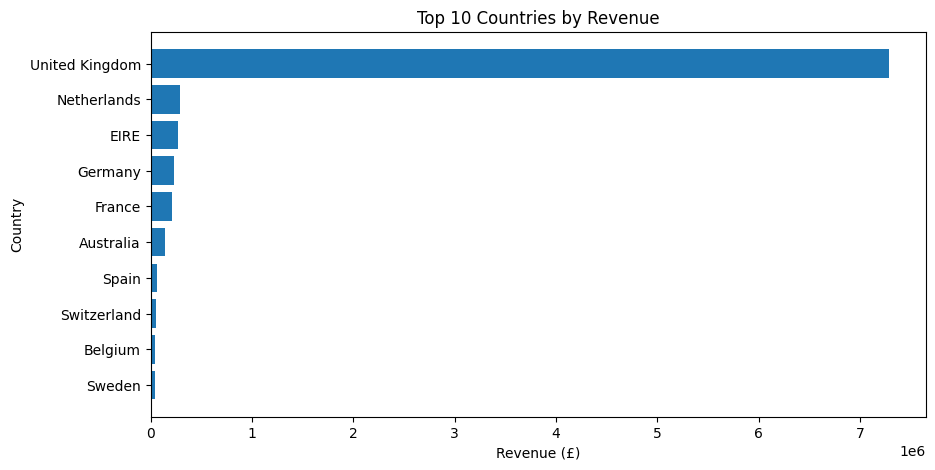

In [32]:
top_countries_revenue = country_customer.head(10)

plt.figure(figsize=(10, 5))

plt.barh(
    top_countries_revenue.index,
    top_countries_revenue["Revenue"]
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Country")

plt.gca().invert_yaxis()

plt.show()

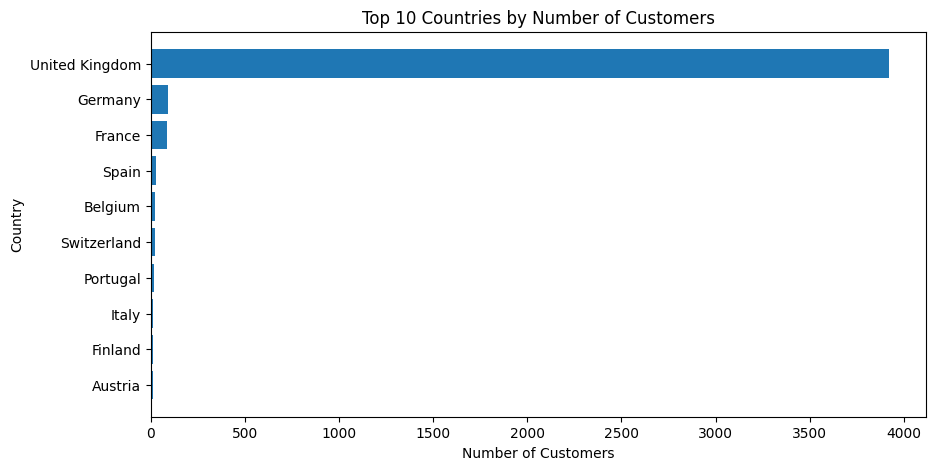

In [33]:
top_countries_customers = (
    country_customer
    .sort_values("Customers", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))

plt.barh(
    top_countries_customers.index,
    top_countries_customers["Customers"]
)

plt.title("Top 10 Countries by Number of Customers")
plt.xlabel("Number of Customers")
plt.ylabel("Country")

plt.gca().invert_yaxis()

plt.show()

**Business Insight:**

The United Kingdom is the business's dominant market, accounting for **3,920 customers** and approximately **£7.29 million in revenue**. This reflects both a large customer base and strong overall revenue contribution.

Germany and France have the next-largest customer bases, with **94 and 87 customers** respectively, while also generating substantial revenue of approximately **£228,678** and **£208,952**.

Interestingly, the **Netherlands generated approximately £285,446 from only 9 customers**, while **EIRE generated approximately £265,262 from just 3 customers**. This indicates that some smaller markets contain exceptionally high-value customers.

The business should therefore continue strengthening its core UK market while investigating opportunities in smaller, high-value markets. Understanding what drives spending in these markets could help the business develop strategies for acquiring and retaining similar high-value customers elsewhere.

## 7. 🎯 RFM Customer Segmentation

The customer-level dataset created during the data preparation stage provides the foundation for segmenting customers based on their purchasing behavior.

This section applies **RFM (Recency, Frequency, and Monetary) analysis** to evaluate customer engagement and value. RFM segmentation helps identify different groups of customers based on how recently they purchased, how frequently they purchase, and how much they spend.

The analysis focuses on the following key areas:

**Recency** – Determine how recently each customer made a purchase and identify customers who are actively engaged with the business.

**Frequency** – Measure how frequently customers place orders and identify customers with strong repeat-purchasing behavior.

**Monetary Value** – Measure the total revenue generated by each customer and identify high-value customers.

**RFM Scoring** – Assign scores to customers based on their Recency, Frequency, and Monetary performance.

**Customer Segmentation** – Group customers into meaningful segments such as Champions, Loyal Customers, Potential Loyalists, New Customers, At Risk Customers, and Lost Customers.

**Segment Performance** – Compare the size and value of each customer segment to understand the overall customer base.

Informative visualizations are created to communicate the distribution and characteristics of the different customer segments. Each visualization is accompanied by a business insight explaining the commercial significance of the findings.

The objective of this analysis is to transform customer transaction data into actionable customer segments that can support **customer retention, targeted marketing, personalized engagement, customer value management, and revenue growth strategies**.

### 7.1 Recency

Recency measures the number of days since a customer made their most recent purchase. Customers with lower recency values have purchased more recently and are generally considered more engaged with the business.

To calculate Recency consistently, the day after the latest transaction date in the dataset is used as the analysis date.

In [34]:
# Set the analysis date

analysis_date = df["InvoiceDate"].max() + pd.Timedelta(days = 1)
print(f"Analysis Date: {analysis_date}")

Analysis Date: 2011-12-10 12:50:00


In [35]:
# Calculate Recency for all customers

customer_summary["Recency"] = (
    analysis_date - customer_summary["LastPurchase"]
).dt.days

customer_summary[["LastPurchase", "Recency"]]

,LastPurchase,Recency
CustomerID,,
12346.0,2011-01-18 10:01:00,326
12347.0,2011-12-07 15:52:00,2
12348.0,2011-09-25 13:13:00,75
12349.0,2011-11-21 09:51:00,19
12350.0,2011-02-02 16:01:00,310
...,...,...
18280.0,2011-03-07 09:52:00,278
18281.0,2011-06-12 10:53:00,181
18282.0,2011-12-02 11:43:00,8


In [36]:
# Understand the Recency Distribution

customer_summary["Recency"].describe()

count    4338.000000
mean       92.536422
std       100.014169
min         1.000000
25%        18.000000
50%        51.000000
75%       142.000000
max       374.000000
Name: Recency, dtype: float64

In [37]:
# Create the Recency Score

customer_summary["R_Score"] = pd.qcut(
    customer_summary["Recency"],
    q=5,
    labels=[5, 4, 3, 2, 1]
)

customer_summary[["Recency", "R_Score"]].head(10)

,Recency,R_Score
CustomerID,,
12346.0,326,1
12347.0,2,5
12348.0,75,2
12349.0,19,4
12350.0,310,1
12352.0,36,3
12353.0,204,1
12354.0,232,1
12355.0,214,1


In [38]:
# R_Score Verification

customer_summary["R_Score"].value_counts().sort_index()

R_Score
5    868
4    904
3    858
2    843
1    865
Name: count, dtype: int64

### 7.2 Frequency

Frequency measures how often customers make purchases from the business. Customers with a higher number of orders demonstrate stronger purchasing engagement and are generally more valuable from a retention perspective.

In [39]:
# Understand the Frequency Distribution

customer_summary["TotalOrders"].describe()

count    4338.000000
mean        4.272015
std         7.697998
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       209.000000
Name: TotalOrders, dtype: float64

In [40]:
# Create the F_Score Column

customer_summary["F_Score"] = pd.qcut(
    customer_summary["TotalOrders"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
)

customer_summary[["TotalOrders", "F_Score"]].head(10)

,TotalOrders,F_Score
CustomerID,,
12346.0,1,1
12347.0,7,5
12348.0,4,4
12349.0,1,1
12350.0,1,1
12352.0,8,5
12353.0,1,1
12354.0,1,1
12355.0,1,1


In [41]:
# Verify the F_Score 

customer_summary["F_Score"].value_counts().sort_index()

F_Score
1    868
2    867
3    868
4    867
5    868
Name: count, dtype: int64

### 7.3 Monetary Value

Monetary Value measures the total revenue generated by each customer during the analysis period. Customers with higher monetary values contribute more revenue to the business and are therefore considered more financially valuable.

In [42]:
# Step 1 — Examine the Monetary Distribution

customer_summary["TotalRevenue"].describe()

count      4338.000000
mean       2048.692230
std        8985.229676
min           3.750000
25%         306.482500
50%         668.570000
75%        1660.597500
max      280206.020000
Name: TotalRevenue, dtype: float64

In [43]:
# Step 2 — Create the Monetary Score

customer_summary["M_Score"] = pd.qcut(
    customer_summary["TotalRevenue"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
)

customer_summary[["TotalRevenue", "M_Score"]].head(10)

,TotalRevenue,M_Score
CustomerID,,
12346.0,77183.60,5
12347.0,4310.00,5
12348.0,1797.24,4
12349.0,1757.55,4
12350.0,334.40,2
12352.0,2506.04,5
12353.0,89.00,1
12354.0,1079.40,4
12355.0,459.40,2


In [44]:
# Verify the M_Score

customer_summary["M_Score"].value_counts().sort_index()

M_Score
1    868
2    867
3    868
4    867
5    868
Name: count, dtype: int64

### 7.4 RFM Scoring

The individual Recency, Frequency, and Monetary scores are combined to create an overall RFM score for each customer. The resulting score provides a simple measure of overall customer engagement and value, with higher scores generally representing more valuable and engaged customers.

In [45]:
# Step 1 — Combine the RFM Scores

customer_summary["RFM_Score"] = (
    customer_summary["R_Score"].astype(int)
    + customer_summary["F_Score"].astype(int)
    + customer_summary["M_Score"].astype(int)
)

customer_summary[[
    "R_Score",
    "F_Score",
    "M_Score",
    "RFM_Score"
]].head(10)

,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,
12346.0,1,1,5,7
12347.0,5,5,5,15
12348.0,2,4,4,10
12349.0,4,1,4,9
12350.0,1,1,2,4
12352.0,3,5,5,13
12353.0,1,1,1,3
12354.0,1,1,4,6
12355.0,1,1,2,4


In [46]:
# Examine the RFM Score Distribution

customer_summary["RFM_Score"].value_counts().sort_index()

RFM_Score
3     183
4     361
5     337
6     426
7     377
8     375
9     336
10    342
11    347
12    321
13    286
14    300
15    347
Name: count, dtype: int64

### 7.5 Customer Segmentation

#### 7.5.1 Champions Segment

In [47]:
# Champions Segment

champions = customer_summary[
    (customer_summary["R_Score"].astype(int) >= 4) &
    (customer_summary["F_Score"].astype(int) >= 4) &
    (customer_summary["M_Score"].astype(int) >= 4)
]

print(f"Number of Champions: {len(champions)}")

Number of Champions: 957


In [48]:
# Verifying the Champions Segment   (R_Score ≥ 4,  F_Score ≥ 4,  M_Score ≥ 4)

champions[["R_Score","F_Score","M_Score","RFM_Score"]].head(10)

,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,
12347.0,5,5,5,15
12362.0,5,5,5,15
12364.0,5,4,4,13
12380.0,4,4,5,13
12381.0,5,4,4,13
12388.0,4,4,5,13
12395.0,4,5,5,14
12408.0,4,4,5,13
12415.0,4,5,5,14


### 🏆 Champions — Business Insight

The analysis identifies **957 Champions**, representing customers with very recent purchases, high purchase frequency, and high monetary value. These customers are the strongest contributors to customer value and should be prioritized for **retention, loyalty rewards, personalized offers, and exclusive promotions**.

#### 7.5.2 Loyal_Customers Segment

In [49]:
# Loyal Customers Segment

loyal_customers = customer_summary[
    (customer_summary["R_Score"].astype(int) >= 3) &
    (customer_summary["F_Score"].astype(int) >= 4) &
    (customer_summary["M_Score"].astype(int) >= 3) &
    ~customer_summary.index.isin(champions.index)
]

print(f"Number of Loyal Customers: {len(loyal_customers)}")

Number of Loyal Customers: 453


In [50]:
# Verifying Loyal Customers   (R_Score ≥ 3,  F_Score ≥ 4,  M_Score ≥ 3)

loyal_customers[["R_Score", "F_Score", "M_Score", "RFM_Score"]].head(10)

,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,
12352.0,3,5,5,13
12359.0,3,4,5,12
12370.0,3,4,5,12
12393.0,3,4,4,11
12407.0,3,4,4,11
12421.0,4,4,3,11
12431.0,3,5,5,13
12432.0,3,4,5,12
12457.0,3,5,5,13


In [51]:
print(
    "Champions inside Loyal Customers:",
    len(loyal_customers.index.intersection(champions.index))
)

Champions inside Loyal Customers: 0


### 🤝 Loyal Customers — Business Insight

A total of **453 customers** are classified as Loyal Customers. These customers demonstrate strong purchasing frequency and meaningful monetary value, while showing lower overall RFM scores than the Champions segment.

**Business Insight:**  
Loyal Customers have established a strong relationship with the business through repeated purchases and consistent spending. They represent an important group for **retention and relationship-building strategies**. Personalized recommendations, loyalty rewards, targeted promotions, and cross-selling opportunities can encourage these customers to increase their purchasing activity and potentially progress into the **🏆 Champions** segment.

#### 7.5.3 Potential Loyalists Segment

In [52]:
# Potential Loyalists Segment

potential_loyalists = customer_summary[
    (customer_summary["R_Score"].astype(int) >= 3) &
    (customer_summary["F_Score"].astype(int) == 3) &
    (customer_summary["M_Score"].astype(int).between(3, 4)) &
    ~customer_summary.index.isin(champions.index) &
    ~customer_summary.index.isin(loyal_customers.index)
]

print(f"Number of Potential Loyalists: {len(potential_loyalists)}")

Number of Potential Loyalists: 284


In [53]:
# Verifying Potential Loyalists  (R_Score ≥ 3, F_Score = 3, M_Score = 3 or 4)

potential_loyalists[["R_Score", "F_Score", "M_Score", "RFM_Score"]].head(10)

,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,
12372.0,3,3,4,10
12413.0,3,3,3,9
12427.0,4,3,3,10
12488.0,5,3,4,12
12526.0,5,3,4,12
12541.0,4,3,4,11
12577.0,3,3,3,9
12620.0,4,3,4,11
12628.0,5,3,3,11


In [54]:
print(
    "Champions overlap:",
    len(potential_loyalists.index.intersection(champions.index))
)

print(
    "Loyal Customers overlap:",
    len(potential_loyalists.index.intersection(loyal_customers.index))
)

Champions overlap: 0
Loyal Customers overlap: 0


### 🌱 Potential Loyalists — Business Insight

A total of **284 customers** are classified as Potential Loyalists. These customers demonstrate relatively recent purchasing activity, moderate purchase frequency, and moderate-to-high monetary value.

**Business Insight:**  
Potential Loyalists represent a valuable opportunity for customer development. With targeted **loyalty incentives, personalized recommendations, follow-up campaigns, and relevant promotions**, the business can encourage these customers to purchase more frequently and increase their overall spending, potentially moving them into the **🤝 Loyal Customers** or **🏆 Champions** segments.

#### 7.5.4 New Customers Segment

In [55]:
# New Customers Segment

new_customers = customer_summary[
    (customer_summary["R_Score"].astype(int) == 5) &
    (customer_summary["F_Score"].astype(int) <= 2) &
    ~customer_summary.index.isin(champions.index) &
    ~customer_summary.index.isin(loyal_customers.index) &
    ~customer_summary.index.isin(potential_loyalists.index)
]

print(f"Number of New Customers: {len(new_customers)}")

Number of New Customers: 99


In [56]:
# Verifying New Customers  (R_Score = 5 → very recent purchase, F_Score ≤ 2 → low purchase frequency)

new_customers[
    ["R_Score", "F_Score", "M_Score", "RFM_Score"]
].head(10)

,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,
12358.0,5,2,4,11
12367.0,5,1,1,7
12375.0,5,2,2,9
12442.0,5,1,1,7
12478.0,5,1,3,9
12479.0,5,1,3,9
12558.0,5,1,2,8
12572.0,5,2,4,11
12587.0,5,1,1,7


In [57]:
# New Customers Overlap Check

print(
    "Champions overlap:",
    len(new_customers.index.intersection(champions.index))
)

print(
    "Loyal Customers overlap:",
    len(new_customers.index.intersection(loyal_customers.index))
)

print(
    "Potential Loyalists overlap:",
    len(new_customers.index.intersection(potential_loyalists.index))
)

Champions overlap: 0
Loyal Customers overlap: 0
Potential Loyalists overlap: 0


### 🆕 New Customers — Business Insight

A total of **99 customers** are classified as New Customers. These customers have made purchases very recently but have relatively low purchase frequency, indicating that they are still developing their relationship with the business.

**Business Insight:**  
New Customers represent an important opportunity for future growth. Since they have recently engaged with the business but have not yet developed strong repeat-purchasing behavior, targeted **onboarding, personalized recommendations, follow-up communications, and introductory loyalty incentives** can encourage a second purchase and help convert them into **🌱 Potential Loyalists, 🤝 Loyal Customers, or 🏆 Champions**.

#### 7.5.5 At-Risk Customers Segment

In [58]:
# At-Risk Customers Segment

at_risk_customers = customer_summary[
    (customer_summary["R_Score"].astype(int) <= 2) &
    (customer_summary["F_Score"].astype(int) >= 3) &
    (customer_summary["M_Score"].astype(int) >= 3) &
    ~customer_summary.index.isin(champions.index) &
    ~customer_summary.index.isin(loyal_customers.index) &
    ~customer_summary.index.isin(potential_loyalists.index) &
    ~customer_summary.index.isin(new_customers.index)
]

print(f"Number of At-Risk Customers: {len(at_risk_customers)}")

Number of At-Risk Customers: 453


In [59]:
# Verifying At-Risk Customers
"""
R_Score ≤ 2 → haven't purchased recently
F_Score ≥ 3 → reasonable purchase frequency
M_Score ≥ 3 → meaningful monetary value
Exclude Champions
Exclude Loyal Customers
Exclude Potential Loyalists
Exclude New Customer
"""
at_risk_customers[
    ["R_Score", "F_Score", "M_Score", "RFM_Score"]
].head(10)

,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,
12348.0,2,4,4,10
12383.0,1,4,4,9
12399.0,2,4,4,10
12409.0,2,3,5,10
12412.0,2,3,4,9
12414.0,1,3,3,7
12422.0,2,3,3,8
12455.0,2,4,5,11
12502.0,2,4,5,11


In [60]:
print(
    "Champions overlap:",
    len(at_risk_customers.index.intersection(champions.index))
)

print(
    "Loyal Customers overlap:",
    len(at_risk_customers.index.intersection(loyal_customers.index))
)

print(
    "Potential Loyalists overlap:",
    len(at_risk_customers.index.intersection(potential_loyalists.index))
)

print(
    "New Customers overlap:",
    len(at_risk_customers.index.intersection(new_customers.index))
)

Champions overlap: 0
Loyal Customers overlap: 0
Potential Loyalists overlap: 0
New Customers overlap: 0


#### ⚠️ At-Risk Customers — Business Insight

A total of **453 customers** are classified as At-Risk. These customers have relatively low Recency scores, indicating that they have not purchased recently, but they have demonstrated meaningful purchase frequency and monetary value.

**Business Insight:**  
At-Risk customers represent a significant **customer retention and revenue recovery opportunity**. Their previous purchasing activity indicates an established relationship with the business, but their recent inactivity suggests a risk of customer churn. The business should prioritize **targeted reactivation campaigns, personalized offers, loyalty incentives, and direct engagement** to encourage these customers to return and prevent further loss of valuable customers.

#### 7.5.6 — Hibernating Customers

In [61]:
# Identify customers already assigned to a segment

assigned_customers = (
    champions.index
    .union(loyal_customers.index)
    .union(potential_loyalists.index)
    .union(new_customers.index)
    .union(at_risk_customers.index)
)

# Create the remaining customer group

remaining_customers = customer_summary[
    ~customer_summary.index.isin(assigned_customers)
].copy()

print(f"Remaining Customers: {len(remaining_customers)}")

Remaining Customers: 2092


In [62]:
# Hibernating Customers Segment

hibernating_customers = remaining_customers[
    (remaining_customers["R_Score"].astype(int) <= 2) &
    (remaining_customers["F_Score"].astype(int) <= 2) &
    (remaining_customers["M_Score"].astype(int) <= 4)
]

print(f"Number of Hibernating Customers: {len(hibernating_customers)}")

Number of Hibernating Customers: 1050


In [63]:
hibernating_customers[
    ["R_Score", "F_Score", "M_Score", "RFM_Score"]
].describe()

,RFM_Score
count,1050.000000
mean,4.664762
std,1.246538
min,3.000000
25%,4.000000
50%,4.000000
75%,5.000000
max,8.000000


In [64]:
hibernating_customers[
    ["R_Score", "F_Score", "M_Score", "RFM_Score"]
].value_counts().head(15)

R_Score  F_Score  M_Score  RFM_Score
1        1        1        3            183
         2        1        4            153
         1        2        4            127
         2        2        5             90
2        1        1        4             81
         2        1        5             65
                  2        6             61
         1        2        5             61
         2        3        7             50
1        2        3        6             43
2        1        3        6             40
1        1        3        5             33
2        2        4        8             22
1        1        4        6             17
2        1        4        7             14
Name: count, dtype: int64

#### 😴 Hibernating Customers — Business Insight

A total of **1,050 customers** are classified as Hibernating Customers. These customers have not purchased recently, have relatively low purchase frequency, and have low-to-moderate monetary value.

**Business Insight:**  
Hibernating Customers represent a **low-engagement customer base with a relatively high risk of becoming permanently inactive**. Since their historical purchasing activity and spending are limited, the business should use **low-cost reactivation strategies**, such as personalized reminders, targeted discounts, product recommendations, and occasional email campaigns. Customers who respond positively can be monitored and gradually moved toward more engaged segments.

In [65]:
remaining_after_hibernating = remaining_customers[
    ~remaining_customers.index.isin(hibernating_customers.index)
].copy()

print(
    f"Customers remaining after Hibernating segment: "
    f"{len(remaining_after_hibernating)}"
)

Customers remaining after Hibernating segment: 1042


In [66]:
remaining_after_hibernating[
    ["R_Score", "F_Score", "M_Score", "RFM_Score"]
].describe()

,RFM_Score
count,1042.000000
mean,7.419386
std,1.622882
min,5.000000
25%,6.000000
50%,7.000000
75%,8.000000
max,13.000000


In [67]:
remaining_after_hibernating[
    ["R_Score", "F_Score", "M_Score", "RFM_Score"]
].value_counts().head(15)

R_Score  F_Score  M_Score  RFM_Score
3        2        1        6            68
         1        1        5            67
                  2        6            58
         2        2        7            57
1        3        2        6            56
4        1        1        6            55
2        3        2        7            53
4        3        2        9            50
3        3        2        8            49
4        2        2        8            45
                  1        7            39
3        2        3        8            35
5        3        2        10           33
4        1        2        7            29
3        1        3        7            28
Name: count, dtype: int64

#### 7.5.7 Occasional Customers 

In [68]:
# Occasional Customers Segment

occasional_customers = remaining_after_hibernating[
    (remaining_after_hibernating["R_Score"].astype(int) >= 3) &
    (remaining_after_hibernating["F_Score"].astype(int) <= 2) &
    (remaining_after_hibernating["M_Score"].astype(int) <= 4) &
    ~remaining_after_hibernating.index.isin(new_customers.index)
].copy()

print(f"Number of Occasional Customers: {len(occasional_customers)}")

Number of Occasional Customers: 559


In [69]:
occasional_customers[
    ["R_Score", "F_Score", "M_Score", "RFM_Score"]
].head(10)

,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,
12349.0,4,1,4,9
12371.0,3,2,4,9
12374.0,4,1,3,8
12384.0,4,2,3,9
12391.0,4,1,2,7
12394.0,3,2,4,9
12398.0,3,1,4,8
12403.0,3,1,2,6
12420.0,3,1,3,7


In [70]:
print(
    "Champions overlap:",
    len(occasional_customers.index.intersection(champions.index))
)

print(
    "Loyal Customers overlap:",
    len(occasional_customers.index.intersection(loyal_customers.index))
)

print(
    "Potential Loyalists overlap:",
    len(occasional_customers.index.intersection(potential_loyalists.index))
)

print(
    "New Customers overlap:",
    len(occasional_customers.index.intersection(new_customers.index))
)

print(
    "At-Risk Customers overlap:",
    len(occasional_customers.index.intersection(at_risk_customers.index))
)

print(
    "Hibernating Customers overlap:",
    len(occasional_customers.index.intersection(hibernating_customers.index))
)

Champions overlap: 0
Loyal Customers overlap: 0
Potential Loyalists overlap: 0
New Customers overlap: 0
At-Risk Customers overlap: 0
Hibernating Customers overlap: 0


### 🌤️ Occasional Customers — Business Insight

A total of **559 customers** are classified as Occasional Customers. These customers have relatively recent purchasing activity but purchase infrequently and generate low-to-moderate monetary value.

**Business Insight:**  
Occasional Customers represent an opportunity to increase **purchase frequency and customer value**. Since they have shown recent engagement with the business, targeted product recommendations, personalized promotions, reminder campaigns, and incentives for repeat purchases can encourage them to buy more frequently and potentially progress into the **🌱 Potential Loyalists** or **🤝 Loyal Customers** segments.

#### 7.5.8 Other Customers 

In [71]:
# Other Customers Segment

other_customers = remaining_after_hibernating[
    ~remaining_after_hibernating.index.isin(occasional_customers.index)
].copy()

print(f"Number of Other Customers: {len(other_customers)}")

Number of Other Customers: 483


#### 📦 Other Customers — Business Insight

A total of **483 customers** are classified as Other Customers. These customers do not strongly fit any of the defined RFM segments based on their purchasing recency, frequency, and monetary value.

**Business Insight:**  
Other Customers represent a **mixed group with varied purchasing behaviors** that do not warrant a specific strategic classification at this stage. The business can monitor their future purchasing behavior and use additional customer data, such as product preferences, purchase channels, or customer demographics, to develop more targeted strategies. Customers who show changes in engagement can be reassigned to more actionable segments during future RFM evaluations.

#### 7.6 Final RFM Segmentation Audit


In [72]:
# Final RFM Segmentation Audit

segments = {
    "Champions": champions,
    "Loyal Customers": loyal_customers,
    "Potential Loyalists": potential_loyalists,
    "New Customers": new_customers,
    "At-Risk Customers": at_risk_customers,
    "Hibernating Customers": hibernating_customers,
    "Occasional Customers": occasional_customers,
    "Other Customers": other_customers
}

# Total customers in all segments
total_segmented = sum(len(segment) for segment in segments.values())

# Check for duplicate assignments
all_customer_ids = []

for segment in segments.values():
    all_customer_ids.extend(segment.index)

duplicate_assignments = len(all_customer_ids) - len(set(all_customer_ids))

# Check for unclassified customers
unclassified = len(customer_summary) - total_segmented

print(f"Total Customers: {len(customer_summary):,}")
print(f"Total Segmented: {total_segmented:,}")
print(f"Duplicate Assignments: {duplicate_assignments:,}")
print(f"Unclassified Customers: {unclassified:,}")

Total Customers: 4,338
Total Segmented: 4,338
Duplicate Assignments: 0
Unclassified Customers: 0


#### 7.7 Segment Distribution Summary


In [73]:
# Segment Distribution Summary

segment_summary = pd.DataFrame({
    "Segment": [
        "Champions",
        "Loyal Customers",
        "Potential Loyalists",
        "New Customers",
        "At-Risk Customers",
        "Hibernating Customers",
        "Occasional Customers",
        "Other Customers"
    ],
    "Customers": [
        len(champions),
        len(loyal_customers),
        len(potential_loyalists),
        len(new_customers),
        len(at_risk_customers),
        len(hibernating_customers),
        len(occasional_customers),
        len(other_customers)
    ]
})

segment_summary

,Segment,Customers
0,Champions,957
1,Loyal Customers,453
2,Potential Loyalists,284
3,New Customers,99
4,At-Risk Customers,453
5,Hibernating Customers,1050
6,Occasional Customers,559
7,Other Customers,483


#### 7.8 Customer Segment Distribution Chart

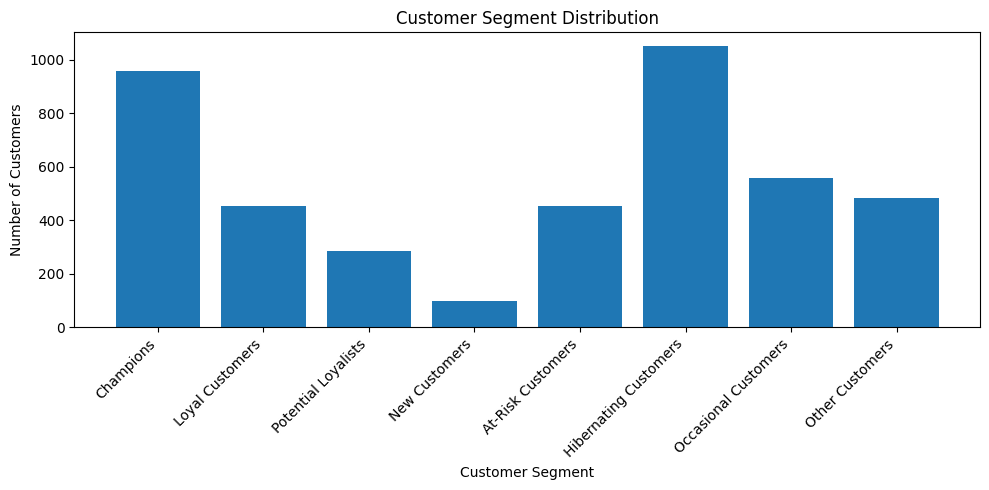

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    segment_summary["Segment"],
    segment_summary["Customers"]
)

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

#### 📊 Customer Segment Distribution — Business Insight

The customer base of **4,338 customers** is distributed across eight behavioral segments. **Hibernating Customers** represent the largest group, with **1,050 customers**, followed by **Champions** with **957 customers**.

**Business Insight:**  
The large number of Hibernating Customers indicates a significant **customer reactivation opportunity**. At the same time, the strong number of Champions represents a valuable group that should be protected through personalized engagement and loyalty strategies.

The relatively small number of New Customers (**99**) suggests that customer acquisition is an area that may require attention. The business should focus on converting New and Potential Loyalist customers into higher-value segments while preventing Champions and Loyal Customers from becoming At-Risk or Hibernating customers.

Overall, the segmentation reveals that the business has a strong base of valuable customers but also a substantial portion of customers who require **retention and reactivation efforts**.

## 8. 💰 Customer Value Analysis

The RFM segmentation developed in the previous section provides a foundation for understanding customer behavior and engagement. This section extends the analysis by evaluating the **financial value and revenue contribution of customers**.

The analysis focuses on:

- **Customer Lifetime Value (CLV)** – Estimate the value generated by customers based on their purchasing behavior.
- **Pareto (80/20) Analysis** – Examine revenue concentration across the customer base.
- **High-Value Customers** – Identify customers contributing significantly to total revenue.
- **Revenue Contribution by Segment** – Compare revenue generated across RFM segments.
- **High-Potential Customers** – Identify customers with opportunities for future growth.
- **Retention Strategies** – Develop strategies for retaining valuable customers and strengthening promising segments.
- **Business Recommendations** – Translate customer value findings into actionable business strategies.

Informative visualizations are created to communicate the findings, with each visualization supported by a relevant business insight.

**Objective:** Identify **where customer value comes from and how the business can maximize that value through targeted retention and growth strategies.**

In [75]:
customer_summary.columns

Index(['TotalRevenue', 'TotalOrders', 'TotalQuantity', 'FirstPurchase',
       'LastPurchase', 'AverageOrderValue', 'CustomerTenure',
       'PurchaseFrequency', 'RevenueBand', 'CustomerType', 'Recency',
       'R_Score', 'F_Score', 'M_Score', 'RFM_Score'],
      dtype='object')

### 8.1 💵 Customer Lifetime Value (CLV)


In [76]:
# CLV = Average Order Value × Purchase Frequency × Customer Tenure

# Checking CustomerTenure
customer_summary['CustomerTenure'] = customer_summary['CustomerTenure'].replace(0, 1)

# Calculate Estimated CLV
customer_summary['EstimatedCLV'] = (
    customer_summary['AverageOrderValue']
    * customer_summary['PurchaseFrequency']
    * customer_summary['CustomerTenure']
)

# Verifying the Result
customer_summary[['TotalRevenue', 'AverageOrderValue',
             'PurchaseFrequency', 'CustomerTenure',
             'EstimatedCLV']].head()

,TotalRevenue,AverageOrderValue,PurchaseFrequency,CustomerTenure,EstimatedCLV
CustomerID,,,,,
12346.0,77183.60,77183.600000,1.000000,1,77183.60
12347.0,4310.00,615.714286,0.019178,365,4310.00
12348.0,1797.24,449.310000,0.014184,282,1797.24
12349.0,1757.55,1757.550000,1.000000,1,1757.55
12350.0,334.40,334.400000,1.000000,1,334.40


In [77]:
customer_summary['EstimatedCLV'].describe()

count      4338.000000
mean       2048.692230
std        8985.229676
min           3.750000
25%         306.482500
50%         668.570000
75%        1660.597500
max      280206.020000
Name: EstimatedCLV, dtype: float64

#### Customer Lifetime Value (CLV) — Business Insight

The estimated CLV analysis shows a **highly uneven distribution of customer value**. Across **4,338 customers**, the average estimated CLV is **2,048.69**, while the median is substantially lower at **668.57**. This large difference indicates that a relatively small number of customers generate exceptionally high value and significantly influence the overall average.

The highest estimated CLV is **280,206.02**, compared with a minimum of **3.75**, highlighting the substantial variation in customer value.

**Business implication:** The business should prioritize the **retention and development of high-value customers**, while identifying opportunities to increase the value of lower-value customers through repeat purchases, cross-selling, upselling, and targeted engagement strategies.

### 8.2 📈 Pareto Analysis


In [78]:
# Sort Customers by Revenue

pareto_df = customer_summary[['TotalRevenue']].sort_values(
    by='TotalRevenue',
    ascending=False
).copy()
pareto_df.head(10)

,TotalRevenue
CustomerID,
14646.0,280206.02
18102.0,259657.30
17450.0,194390.79
16446.0,168472.50
14911.0,143711.17
12415.0,124914.53
14156.0,117210.08
17511.0,91062.38
16029.0,80850.84


In [79]:
# Add Cumulative Revenue

pareto_df['CumulativeRevenue'] = pareto_df['TotalRevenue'].cumsum()

pareto_df['CumulativeRevenuePct'] = (
    pareto_df['CumulativeRevenue']
    / pareto_df['TotalRevenue'].sum()
) * 100
pareto_df.head(10)

,TotalRevenue,CumulativeRevenue,CumulativeRevenuePct
CustomerID,,,
14646.0,280206.02,280206.02,3.152907
18102.0,259657.30,539863.32,6.074598
17450.0,194390.79,734254.11,8.261904
16446.0,168472.50,902726.61,10.157574
14911.0,143711.17,1046437.78,11.774627
12415.0,124914.53,1171352.31,13.180178
14156.0,117210.08,1288562.39,14.499038
17511.0,91062.38,1379624.77,15.523681
16029.0,80850.84,1460475.61,16.433423


In [80]:
# Find the 80% revenue point

pareto_80 = pareto_df[
    pareto_df['CumulativeRevenuePct'] >= 80
].iloc[0]

pareto_80

TotalRevenue            1.591450e+03
CumulativeRevenue       7.110648e+06
CumulativeRevenuePct    8.000975e+01
Name: 15611.0, dtype: float64

In [81]:
# Calculate the customer percentage

customers_for_80 = pareto_df.index.get_loc(pareto_80.name) + 1

customer_percentage_80 = (
    customers_for_80 / len(pareto_df)
) * 100

customers_for_80, customer_percentage_80

(1130, 26.0488704472107)

####  Pareto (80/20) Analysis -  Business Insight

The Pareto analysis shows that **1,130 customers (26.05% of the customer base) generate approximately 80% of total revenue**, while the remaining **73.95% of customers contribute approximately 20%**.

This indicates a **high concentration of revenue among a relatively small group of customers**. Although the result does not follow the traditional 80/20 rule exactly, it demonstrates that a minority of customers contributes a disproportionately large share of business revenue.

**Business implication:** The company should prioritize the retention and development of high-value customers while using targeted strategies to increase the value of lower-contributing customer groups.

### 8.3 🏆 High-Value Customers


In [82]:
# Top Ten Customers by Revenue

top_10_customers = pareto_df.head(10)

top_10_customers

,TotalRevenue,CumulativeRevenue,CumulativeRevenuePct
CustomerID,,,
14646.0,280206.02,280206.02,3.152907
18102.0,259657.30,539863.32,6.074598
17450.0,194390.79,734254.11,8.261904
16446.0,168472.50,902726.61,10.157574
14911.0,143711.17,1046437.78,11.774627
12415.0,124914.53,1171352.31,13.180178
14156.0,117210.08,1288562.39,14.499038
17511.0,91062.38,1379624.77,15.523681
16029.0,80850.84,1460475.61,16.433423


In [83]:
# Calculate the exact revenue contribution

top_10_revenue = top_10_customers['TotalRevenue'].sum()

total_revenue = customer_summary['TotalRevenue'].sum()

top_10_revenue_pct = (top_10_revenue / total_revenue) * 100

top_10_revenue, top_10_revenue_pct

(np.float64(1537659.2100000002), np.float64(17.301901125514355))

####  High-Value Customers — Business Insight

The analysis shows that the **top 10 customers generated 1,537,659.21 in revenue**, representing **17.30% of total revenue** from the 4,338 customers analyzed.

This indicates that a very small group of customers contributes a substantial share of the company's revenue, highlighting the financial importance of high-value customers.

**Business implication:** The business should prioritize the retention of these high-value customers through personalized offers, loyalty rewards, exclusive benefits, and proactive relationship management. Losing even a small number of these customers could have a meaningful impact on overall revenue.

### 8.4 💰 Revenue Contribution by Segment


In [84]:
# Check RFM Segments

segment_summary.columns

segment_summary

,Segment,Customers
0,Champions,957
1,Loyal Customers,453
2,Potential Loyalists,284
3,New Customers,99
4,At-Risk Customers,453
5,Hibernating Customers,1050
6,Occasional Customers,559
7,Other Customers,483


In [85]:
# Revenue Contribution by Customer Segment

segment_revenue = pd.DataFrame({
    'Segment': segments.keys(),
    'Customers': [len(df) for df in segments.values()],
    'Revenue': [
        df['TotalRevenue'].sum()
        for df in segments.values()
    ]
})

total_revenue = customer_summary['TotalRevenue'].sum()

segment_revenue['RevenueContributionPct'] = (
    segment_revenue['Revenue'] / total_revenue
) * 100

segment_revenue = segment_revenue.sort_values(
    'Revenue',
    ascending=False
).reset_index(drop=True)

segment_revenue


,Segment,Customers,Revenue,RevenueContributionPct
0,Champions,957,5791640.740,65.168143
1,Loyal Customers,453,877946.651,9.878747
2,At-Risk Customers,453,739477.551,8.320678
3,Other Customers,483,564147.301,6.347844
4,Hibernating Customers,1050,383205.561,4.311869
5,Potential Loyalists,284,259360.350,2.918350
6,Occasional Customers,559,222035.130,2.498362
7,New Customers,99,49413.610,0.556007


#### 8.4 Revenue Contribution by Customer Segment — Business Insight

The analysis shows that **Champions are the dominant revenue-generating segment**, contributing **65.17% of total revenue** from 957 customers. Loyal Customers contribute **9.88%**, while At-Risk Customers contribute **8.32%**.

The remaining segments each contribute less than 7% of total revenue, with New Customers contributing only **0.56%**.

**Business implication:** The business is highly dependent on its Champions segment. Retaining these customers should be the highest priority, while **At-Risk and Potential Loyalist customers represent important opportunities for targeted retention and growth strategies**.

### 8.5 🚀 High-Potential Customer Groups


In [86]:
high_potential_segments = [
    'Loyal Customers',
    'Potential Loyalists',
    'At-Risk Customers'
]

high_potential = segment_revenue[
    segment_revenue['Segment'].isin(high_potential_segments)
].copy()

high_potential_customers = high_potential['Customers'].sum()
high_potential_revenue = high_potential['Revenue'].sum()

high_potential_revenue_pct = (
    high_potential_revenue / total_revenue
) * 100

high_potential_customers, high_potential_revenue, high_potential_revenue_pct

(np.int64(1190),
 np.float64(1876784.5519999997),
 np.float64(21.117774693780646))

#### 8.5 High-Potential Customer Groups — Business Insight

The analysis identifies **1,190 customers** across the **Loyal Customers, Potential Loyalists, and At-Risk Customers** segments, generating a combined **1,876,784.55**, equivalent to **21.12% of total revenue**.

These segments represent a significant opportunity for future revenue growth. Loyal Customers can be developed into Champions, Potential Loyalists can be encouraged toward repeat purchasing, while At-Risk Customers can be targeted with reactivation and retention campaigns.

**Business implication:** The business should prioritize these groups with **personalized promotions, loyalty incentives, cross-selling, and targeted re-engagement campaigns** to increase customer value and prevent revenue loss.

### 8.6 🔄 Customer Retention Strategies

| Customer Segment | Objective | Recommended Strategy |
|---|---|---|
| **Champions** | Retain high-value customers | VIP rewards, exclusive offers, personalized communication, early access to new products, and proactive relationship management. |
| **Loyal Customers** | Develop into Champions | Loyalty incentives, personalized recommendations, cross-selling, and rewards for increased purchase frequency. |
| **Potential Loyalists** | Increase engagement | Targeted promotions, product recommendations, limited-time offers, and incentives for repeat purchases. |
| **At-Risk Customers** | Prevent customer loss | Win-back campaigns, personalized discounts, customer feedback initiatives, and reminders based on previous purchasing behavior. |
| **Hibernating Customers** | Reactivate valuable customers | Re-engagement campaigns, targeted incentives, and personalized offers based on previous purchase history. |
| **New Customers** | Encourage repeat purchases | Welcome campaigns, first-to-second purchase incentives, product recommendations, and onboarding communication. |
| **Occasional Customers** | Increase purchase frequency | Personalized promotions, bundles, seasonal campaigns, and incentives for repeat purchases. |
| **Other Customers** | Understand and develop value | Monitor behavior, identify emerging patterns, and test targeted campaigns to move customers into higher-value segments. |

## 9. 📊 Data Visualization & Insights

To communicate the key findings from the customer analytics analysis, a series of visualizations are created to highlight customer behavior, customer value, revenue concentration, and customer segmentation.

The visualizations provide a clear view of the patterns identified during the analysis and support the interpretation of key business findings.

The following visualizations are included:

- **One-Time vs. Repeat Customers** — Compares customers based on their purchasing frequency.
- **Customer Distribution by RFM Segment** — Shows the number of customers across different RFM segments.
- **Revenue Contribution by Customer Segment** — Highlights the proportion of total revenue generated by each customer segment.
- **Customer Lifetime Value (CLV) Distribution** — Shows the distribution of estimated customer lifetime value across the customer base.
- **Pareto Revenue Analysis** — Illustrates the concentration of revenue among customers and identifies the proportion of customers responsible for approximately 80% of revenue.
- **Top 10 High-Value Customers** — Highlights the customers generating the highest total revenue.

These visualizations transform the analytical results into clear business insights, making it easier to identify high-value customers, revenue concentration, growth opportunities, and areas requiring targeted retention strategies.

#### Visualization 1 — One-Time vs. Repeat Customers

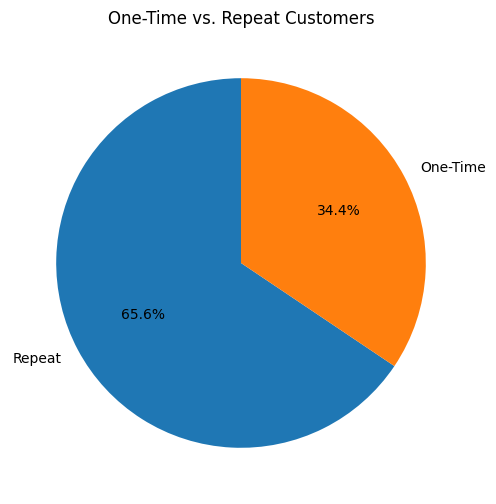

In [87]:
plt.figure(figsize=(6, 6))

plt.pie(
    customer_type_counts,
    labels=customer_type_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("One-Time vs. Repeat Customers")

plt.savefig(
    "one_time_vs_repeat_customers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Visualization 2 — Revenue Contribution by Segment

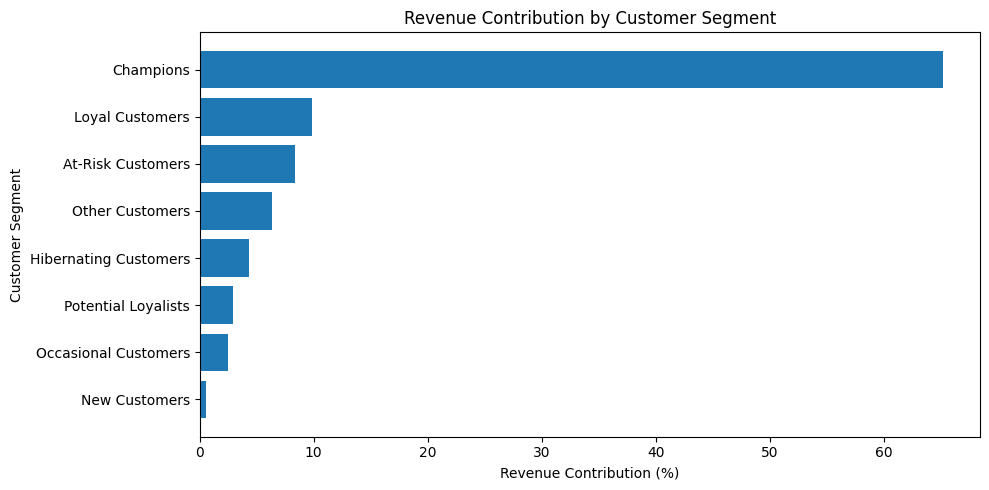

In [88]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.barh(
    segment_revenue['Segment'],
    segment_revenue['RevenueContributionPct']
)

plt.xlabel('Revenue Contribution (%)')
plt.ylabel('Customer Segment')
plt.title('Revenue Contribution by Customer Segment')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig('revenue_contribution_by_segment.png', dpi=300, bbox_inches='tight')
plt.show()

#### Visualization 3 — Customer Lifetime Value (CLV)

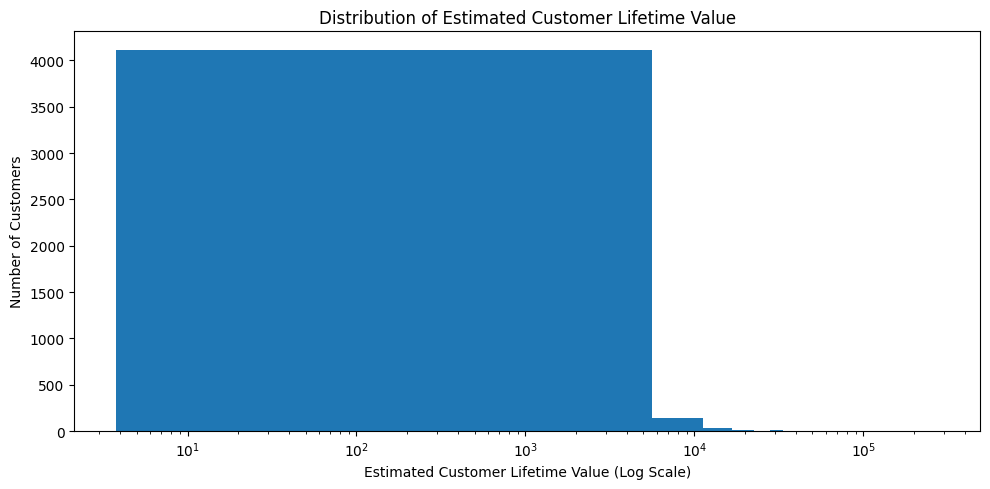

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(customer_summary['EstimatedCLV'], bins=50)

plt.xscale('log')

plt.xlabel('Estimated Customer Lifetime Value (Log Scale)')
plt.ylabel('Number of Customers')
plt.title('Distribution of Estimated Customer Lifetime Value')

plt.tight_layout()
plt.savefig('clv_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

#### Visualization 4 — Pareto Analysis

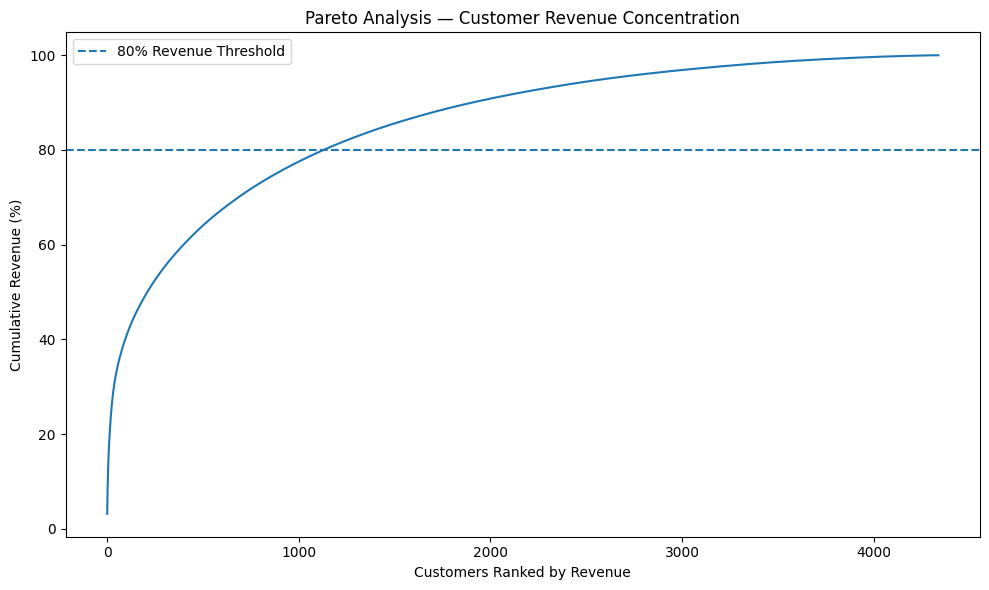

In [90]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(pareto_df) + 1),
    pareto_df['CumulativeRevenuePct']
)

plt.axhline(
    y=80,
    linestyle='--',
    label='80% Revenue Threshold'
)

plt.xlabel('Customers Ranked by Revenue')
plt.ylabel('Cumulative Revenue (%)')
plt.title('Pareto Analysis — Customer Revenue Concentration')

plt.legend()

plt.tight_layout()
plt.savefig('pareto_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

#### Visualization 5 — Top 10 High-Value Customers

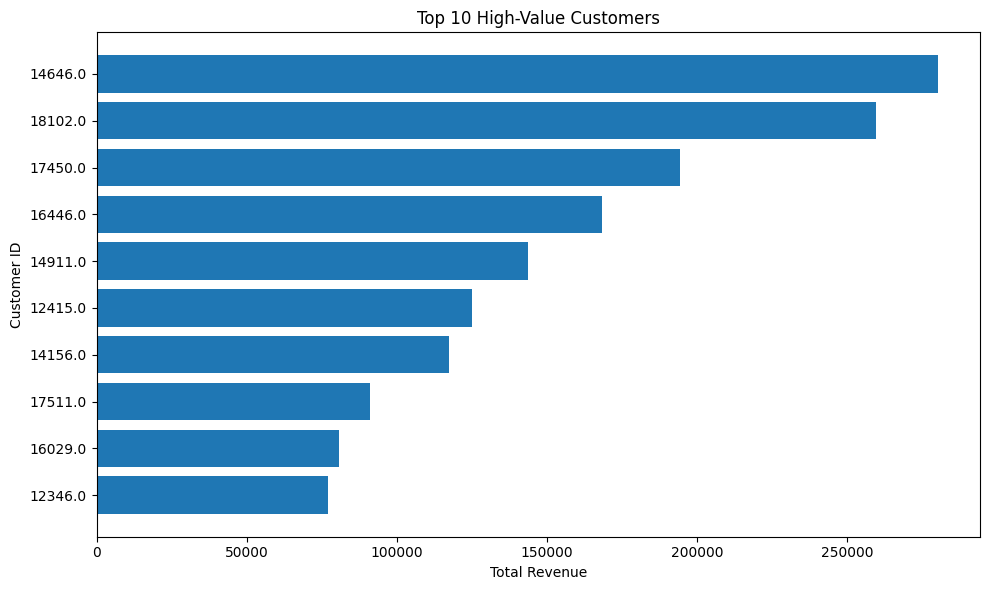

In [91]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_customers.index.astype(str),
    top_10_customers['TotalRevenue']
)

plt.xlabel('Total Revenue')
plt.ylabel('Customer ID')
plt.title('Top 10 High-Value Customers')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig('top_10_high_value_customers.png', dpi=300, bbox_inches='tight')
plt.show()

#### Visualization 6 — Customer Segment Distribution

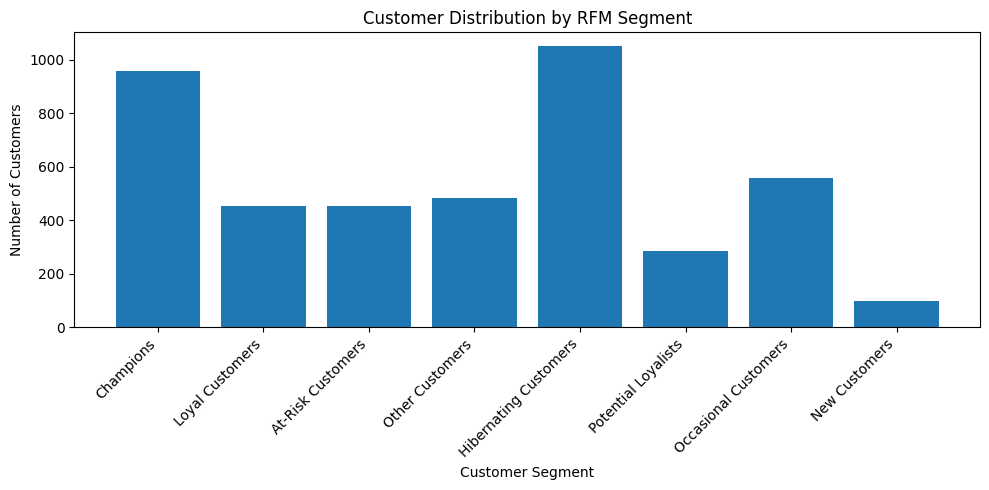

In [92]:
plt.figure(figsize=(10, 5))

plt.bar(
    segment_revenue['Segment'],
    segment_revenue['Customers']
)

plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.title('Customer Distribution by RFM Segment')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('customer_distribution_by_segment.png', dpi=300, bbox_inches='tight')
plt.show()

### Save Charts Into the Visualization Folder

In [93]:
import os

os.makedirs("visualizations", exist_ok=True)

plt.savefig(
    "visualizations/one_time_vs_repeat_customers.png",
    dpi=300,
    bbox_inches="tight"
)
plt.savefig(
    "visualizations/revenue_contribution_by_segment.png",
    dpi=300,
    bbox_inches="tight"
)
plt.savefig(
    "visualizations/clv_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.savefig(
    "visualizations/pareto_analysis.png",
    dpi=300,
    bbox_inches="tight"
)
plt.savefig(
    "visualizations/top_10_high_value_customers.png",
    dpi=300,
    bbox_inches="tight"
)
plt.savefig(
    "visualizations/customer_distribution_by_segment.png",
    dpi=300,
    bbox_inches="tight"
)


<Figure size 640x480 with 0 Axes>

### Verifying Charts Are Successfully Saved

In [94]:
import os

expected_charts = [
    "one_time_vs_repeat_customers.png",
    "revenue_contribution_by_segment.png",
    "clv_distribution.png",
    "pareto_analysis.png",
    "top_10_high_value_customers.png",
    "customer_distribution_by_segment.png"
]

for chart in expected_charts:
    path = os.path.join("visualizations", chart)

    if os.path.exists(path):
        print(f"✅ {chart}")
    else:
        print(f"❌ MISSING: {chart}")

✅ one_time_vs_repeat_customers.png
✅ revenue_contribution_by_segment.png
✅ clv_distribution.png
✅ pareto_analysis.png
✅ top_10_high_value_customers.png
✅ customer_distribution_by_segment.png


### Save Customer_Summary Dataset

In [95]:
customer_summary.to_csv(
    "customer_summary.csv",
    index=True
)
import os

os.path.exists("customer_summary.csv")

True

### Save Clean Df Dataset

In [96]:
df.to_csv(
    "cleaned_transactions.csv",
    index=False
)
import os

os.path.exists("cleaned_transactions.csv")

True

## 10. 💡 Executive Business Recommendations

Based on the Customer Lifetime Value, Pareto analysis, high-value customer analysis, and RFM segment revenue contribution, the following actions are recommended:

##### 1. Prioritize Champions Retention
Champions generate **65.17% of total revenue**, making them the most financially important customer segment. The business should prioritize their retention through VIP loyalty programs, personalized offers, exclusive benefits, and proactive engagement.

##### 2. Protect High-Value Customers
The **top 10 customers contribute 17.30% of total revenue**, creating a significant concentration of revenue among a very small customer group. These customers should receive proactive relationship management and personalized retention strategies to reduce the risk of revenue loss.

##### 3. Convert Loyal Customers into Champions
Loyal Customers contribute **9.88% of total revenue** and represent an important group for further development. Targeted loyalty incentives, cross-selling, upselling, and personalized recommendations can encourage these customers to increase their purchase frequency and value.

##### 4. Develop High-Potential Customers
The **Loyal Customers, Potential Loyalists, and At-Risk Customers** segments contain **1,190 customers** and contribute **21.12% of total revenue**. Targeted engagement and retention campaigns should be used to convert promising customers into higher-value segments and recover customers showing signs of declining engagement.

##### 5. Re-Engage At-Risk and Hibernating Customers
At-Risk and Hibernating customers represent a potential source of recovered revenue. The business should use targeted win-back campaigns, personalized promotions, and customer feedback initiatives to reactivate customers with previous purchasing activity.

##### 6. Increase New Customer Conversion
New Customers contribute only **0.56% of total revenue**, suggesting that many new customers have not yet developed significant purchasing value. Welcome campaigns, second-purchase incentives, personalized recommendations, and timely follow-ups should be used to encourage repeat purchases.

##### 7. Use Customer Segmentation for Targeted Marketing
Marketing activities should be aligned with customer value and behavior rather than treating all customers equally. RFM segmentation can be used to personalize promotions, retention campaigns, and customer communication across different customer groups.

#### Overall Recommendation

The business should adopt a **customer-value-driven retention strategy** that protects high-value revenue sources while developing promising customers and selectively reactivating declining customers. This approach can improve customer retention, increase purchase frequency, and maximize long-term customer value.

# Santa Carlo Arcutis
# Ora Pro Nobis